# 02 · Exploratory data analysis

**Goal:** decide what counts as a *long* disruption, define which disruptions are in scope, and find which
information available **at the start** of a disruption separates long ones from short ones.
The answers become the feature list for notebook 03.

- **Input:** `data/processed/disruptions_clean.parquet` (from notebook 01)
- **Output:** the threshold, the scope rule, a list of candidate features, figures in `reports/figures/`

## Setup

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd().parent
processed_dir = repo_root / "data" / "processed"
figures_dir = repo_root / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

BAR_COLOR = "#2a78d6"

df = pd.read_parquet(processed_dir / "disruptions_clean.parquet")
df.shape

(37777, 15)

## A. Shape of the durations

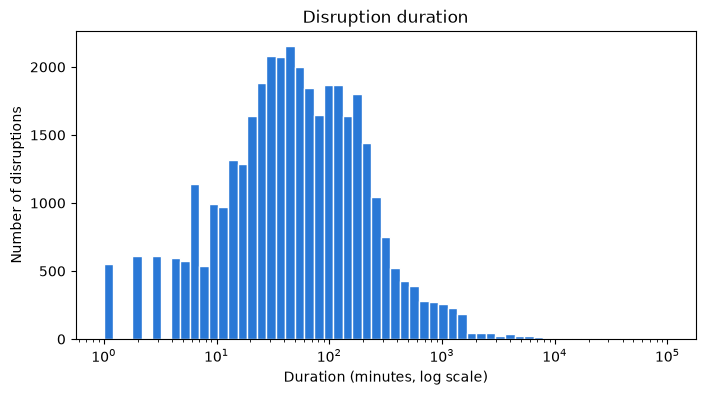

In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["duration_minutes"], bins=np.logspace(0, 5, 60), color=BAR_COLOR, edgecolor="white")
ax.set_xscale("log")
ax.set_xlabel("Duration (minutes, log scale)")
ax.set_ylabel("Number of disruptions")
ax.set_title("Disruption duration")
fig.savefig(figures_dir / "02_duration_hist.png", dpi=150, bbox_inches="tight")
plt.show()

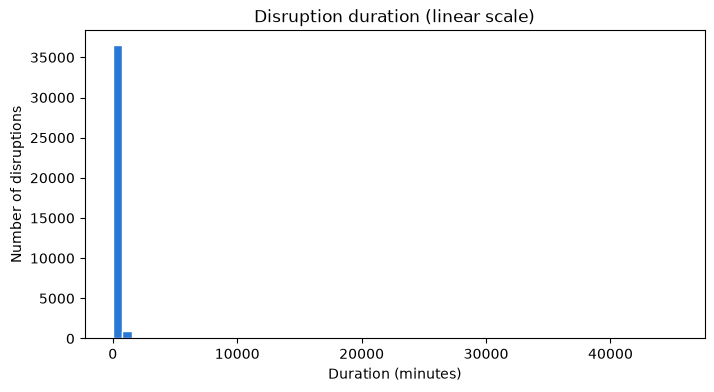

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["duration_minutes"], bins=60, color=BAR_COLOR, edgecolor="white")
ax.set_xlabel("Duration (minutes)")
ax.set_ylabel("Number of disruptions")
ax.set_title("Disruption duration (linear scale)")
plt.show()

**A1.** On the linear scale almost everything falls into the first bar, because a handful of disruptions last
weeks (up to ~45,000 minutes) and stretch the axis. The log scale spreads the durations out and shows the real
shape: one hump around 30–50 minutes (incidents solved quickly, such as a broken-down train being moved), a second
hump around 1.5–3 hours, and a long thin tail of disruptions lasting days.
The log version is the one used from here on.

## B. Choosing the threshold

In [4]:
thresholds = [60, 90, 120, 180, 240]

rows = []
for t in thresholds:
    is_long = df["duration_minutes"] >= t
    rows.append({
        "threshold (min)": t,
        "threshold (h)": f"{t / 60:.1f}h",
        "long disruptions": is_long.sum(),
        "share long": round(is_long.mean(), 3),
    })

threshold_table = pd.DataFrame(rows)
threshold_table

,threshold (min),threshold (h),long disruptions,share long
0,60,1.0h,16915,0.448
1,90,1.5h,13179,0.349
2,120,2.0h,10522,0.279
3,180,3.0h,6829,0.181
4,240,4.0h,4541,0.120


**B2. Decision: a disruption is *long* if it lasts at least 90 minutes.**

- **Meaning (assumption):** around 1.5 hours is the point where waiting stops being sensible and a traveller
  would rather find another route or another way to travel.
- **Shape:** 90 minutes falls in the shallow dip between the two humps of the log histogram, so it roughly separates
  "solved quickly" from "needs real repair work".
- **Balance:** 34.9% of disruptions are long. Balance does not decide between 90 and 120 minutes (27.9%), since both
  are comfortable; it only rules out extremes such as 240 minutes (12%).
- **The threshold is now fixed.** It must not be changed later because a model scores better at another value.

In [5]:
THRESHOLD = 90
df["long"] = df["duration_minutes"] >= THRESHOLD

df.groupby("year")["long"].mean().round(3)

year
2019    0.325
2020    0.320
2021    0.333
2022    0.352
2023    0.396
2024    0.355
2025    0.354
Name: long, dtype: float64

**B3.** The long rate is fairly stable (32–36%) with a slight upward drift, but **2023 stands out at 39.6%**.
This is checked in section C, after looking at causes. Validation (2024) and test (2025) have almost the same
rate (35.5% and 35.4%), so the base rate does not shift between them.

## C. Causes

### C1. Long rate per cause group

In [6]:
group_summary = (
    df.groupby("cause_group")
    .agg(n=("long", "size"), long_rate=("long", "mean"), median_minutes=("duration_minutes", "median"))
    .sort_values("long_rate")
    .round(3)
)
group_summary

,n,long_rate,median_minutes
cause_group,,,
rolling stock,16102,0.147,27.0
unknown,728,0.151,55.0
external,4519,0.155,33.0
engineering work,1197,0.556,113.0
accidents,3764,0.577,118.0
infrastructure,8581,0.580,108.0
logistical,1486,0.630,138.0
weather,341,0.736,170.0
staff,1059,0.941,529.0


The cause group alone separates the data strongly:

- **Mostly short (~15% long):** rolling stock, external, unknown. A broken-down train is usually moved within half an hour.
- **About half long (55–63%):** engineering work, accidents, infrastructure, logistical.
- **Mostly long:** weather (74%) and **staff (94%)**.

### C2. What is inside the *staff* group?

In [7]:
(
    df.loc[df["cause_group"] == "staff"]
    .groupby("cause_en")
    .agg(n=("long", "size"), long_rate=("long", "mean"), median_minutes=("duration_minutes", "median"))
    .sort_values("n", ascending=False)
    .round(2)
)

,n,long_rate,median_minutes
cause_en,,,
staffing problems,563,0.93,430.0
strike,131,0.91,1232.0
strike of Arriva staff,85,0.91,1291.0
staking bij NS,71,0.99,1425.0
strike at ProRail,63,0.98,330.0
staff strikes abroad,60,0.93,973.0
strike of Keolis staff,36,1.00,1267.5
shortage of train traffic controllers,15,1.00,433.0
strike of Breng staff,10,1.00,872.0


The staff group mixes two different things:

- **Strikes** (NS, ProRail, Arriva, Keolis, abroad, ...): announced days in advance; their length is known
  before they start.
- **Staffing problems** (563 rows, the largest single cause in the group): no driver or conductor available.
  This is usually *not* announced in advance.

Note that one strike cause is stored **in Dutch** in the English column: `staking bij NS`.

**Scope decision: remove strikes, keep everything else.**

This project predicts the length of *unexpected* disruptions. For a strike the length is known in advance, so a
prediction adds nothing. Strikes are also almost always long (≥ 91%), which makes them the *easiest* rows to
predict: keeping them would make the model look better than it really is on the disruptions that matter.
The reason to remove them is scope, not score.

Strikes are identified by cause text. A first filter on the word "strike" also matched **`lightning strike`**
(a weather cause), so the filter is restricted to the staff group:

In [8]:
mentions_strike = df["cause_en"].str.contains("strike|staking", case=False)
df.loc[mentions_strike, ["cause_group", "cause_en"]].value_counts()

cause_group  cause_en                  
staff        strike                        131
             strike of Arriva staff         85
             staking bij NS                 71
             strike at ProRail              63
             staff strikes abroad           60
weather      lightning strike               40
staff        strike of Keolis staff         36
             strike of Breng staff          10
             strike of Connexxion staff     10
             strike of Qbuzz staff           6
Name: count, dtype: int64

In [9]:
is_strike = mentions_strike & (df["cause_group"] == "staff")

print("Strike rows removed:", is_strike.sum())
print("Per year:", df.loc[is_strike, "year"].value_counts().sort_index().to_dict())

rows_before = len(df)
df = df.loc[~is_strike].copy()
print(f"Rows: {rows_before:,} -> {len(df):,}")

Strike rows removed: 472
Per year: {2019: 6, 2021: 12, 2022: 109, 2023: 167, 2024: 89, 2025: 89}
Rows: 37,777 -> 37,305


472 strike messages are removed (mostly 2022–2025). The same rule is applied to every year, because it defines the
question, not a data fix. **Notebook 03 must apply exactly the same rule.**

The cause-group picture for the data in scope:

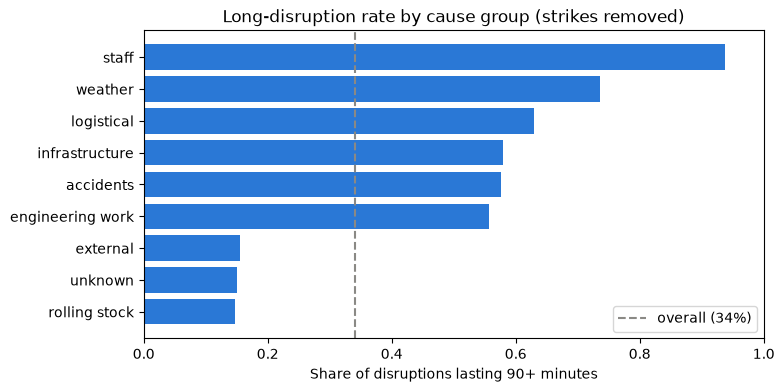

In [10]:
rate_by_group = df.groupby("cause_group")["long"].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(rate_by_group.index, rate_by_group.values, color=BAR_COLOR)
ax.axvline(df["long"].mean(), color="#8a8985", linestyle="--", label=f"overall ({df['long'].mean():.0%})")
ax.set_xlabel(f"Share of disruptions lasting {THRESHOLD}+ minutes")
ax.set_xlim(0, 1)
ax.set_title("Long-disruption rate by cause group (strikes removed)")
ax.legend(loc="lower right")
fig.savefig(figures_dir / "02_long_rate_by_cause_group.png", dpi=150, bbox_inches="tight")
plt.show()

### Engineering work: planned or not?

In [11]:
(
    df.loc[df["cause_group"] == "engineering work"]
    .groupby("cause_en")
    .agg(n=("long", "size"), long_rate=("long", "mean"))
    .sort_values("n", ascending=False)
    .round(2)
)

,n,long_rate
cause_en,,
repair works,725,0.57
over-running engineering works,375,0.47
engineering works,65,0.77
engineering works elsewhere,19,0.84
an earlier disruption,5,1.00
unexpected engineering works,4,0.50
emergency repairs,2,1.00
the construction of a new railway,1,0.00
the construction of a tunnel,1,0.00


Most of the group is `repair works` (725) and `over-running engineering works` (375): unplanned repairs and works
that ran later than planned. Planned works are normally in the timetable and not announced as a disruption.
The group is **kept**.

### C3. Long rate per specific cause

In [12]:
cause_counts = df["cause_en"].value_counts()

cause_summary = (
    df.loc[df["cause_en"].isin(cause_counts[cause_counts >= 100].index)]
    .groupby("cause_en")
    .agg(n=("long", "size"), long_rate=("long", "mean"), median_minutes=("duration_minutes", "median"))
    .sort_values("long_rate")
    .round(3)
)
cause_summary

,n,long_rate,median_minutes
cause_en,,,
person on the railway track,1001,0.037,29.0
people on the railway track,227,0.062,27.0
police action,383,0.078,29.0
an emergency call,1401,0.104,26.0
broken down train,13273,0.115,25.0
an animal on the railway track,237,0.122,42.0
stranded train,2205,0.125,28.0
technical investigation,661,0.151,55.0
garbage on the railway track,236,0.199,39.5


In [13]:
rare_causes = cause_counts[cause_counts < 30]
print("Causes with fewer than 30 rows:", len(rare_causes))
print("Rows they cover:              ", rare_causes.sum())
rare_causes.head(10)

Causes with fewer than 30 rows: 30
Rows they cover:               242


cause_en
collision with an animal                 26
vandalism                                24
large crowds                             20
people along the railway                 19
engineering works elsewhere              19
police investigation                     15
shortage of train traffic controllers    15
flooding                                 14
the expected weather conditions          11
because of a change in the timetable      9
Name: count, dtype: int64

- `cause_en` is much more specific than the group. Inside *external*, for example, a person **on** the track
  (3.7% long) and a person **hit by** a train (86% long) are completely different.
- 30 causes have fewer than 30 rows (about 240 rows in total, 0.6%). Their long rate is mostly luck (with 1 row
  it is 0% or 100%), a model would memorise them, and some may appear in the test year without ever being seen
  in training.
- **Plan for notebook 03:** group rare causes into `"other"`, deciding which ones are rare from the **training
  years only**. `cause_group` still tells the model the broad type.

### Why is 2023 higher?

In [14]:
clean_all = pd.read_parquet(processed_dir / "disruptions_clean.parquet")
clean_all["long"] = clean_all["duration_minutes"] >= THRESHOLD

pd.DataFrame({
    "with strikes": clean_all.groupby("year")["long"].mean(),
    "without strikes": df.groupby("year")["long"].mean(),
}).round(3)

,with strikes,without strikes
year,,
2019,0.325,0.325
2020,0.320,0.320
2021,0.333,0.332
2022,0.352,0.341
2023,0.396,0.378
2024,0.355,0.345
2025,0.354,0.345


2023 had the most strike messages (175). Removing them lowers the 2023 rate from 39.6% to 37.8%, so strikes
explain **part** of the bump. 2023 is still about 5 points above 2019–2021; this remains an open point for
section D and the model error analysis.

### The *unknown* group over time

In [15]:
pd.crosstab(df["year"], df["cause_group"])

cause_group,accidents,engineering work,external,infrastructure,logistical,rolling stock,staff,unknown,weather
year,,,,,,,,,
2019,562,163,465,1274,214,2793,9,24,54
2020,511,148,425,936,229,1959,0,21,42
2021,514,176,564,1088,254,2169,0,16,66
2022,629,221,777,1164,243,2081,132,37,45
2023,533,202,628,1172,228,1904,161,77,58
2024,578,138,804,1383,185,2284,174,249,25
2025,437,149,856,1564,133,2912,111,304,51


In [16]:
unknown = df.loc[df["cause_group"] == "unknown"]
pd.crosstab(unknown["year"], unknown["cause_en"])

cause_en,an earlier disruption,an obstruction on the line,cause yet unknown,multiple disruptions,technical investigation
year,,,,,
2019,0,2,19,2,1
2020,0,3,10,1,7
2021,0,0,7,2,7
2022,0,0,2,2,33
2023,0,0,0,7,70
2024,1,0,3,3,242
2025,0,0,0,3,301


**Distribution shift.** "unknown" grows from about 20 messages a year (2019–2021) to 249 in 2024 and 304 in 2025,
almost all `technical investigation`. NS increasingly publishes "under investigation" instead of a specific cause.

Why it matters: the model learns mostly from 2019–2023, where this category is rare, but it makes up about 4–5%
of the validation and test years. Its long rate also moves around from year to year. Results on this category
should be checked separately in notebook 04.

## D. Time of day and week

- **D1.** Long rate by start hour (`start_time.dt.hour`), as a bar chart. Save it as
  `reports/figures/02_long_rate_by_hour.png`. Explain the pattern.
- **D2.** Long rate by weekday (`dt.dayofweek`) and by month (`dt.month`). Does either matter?

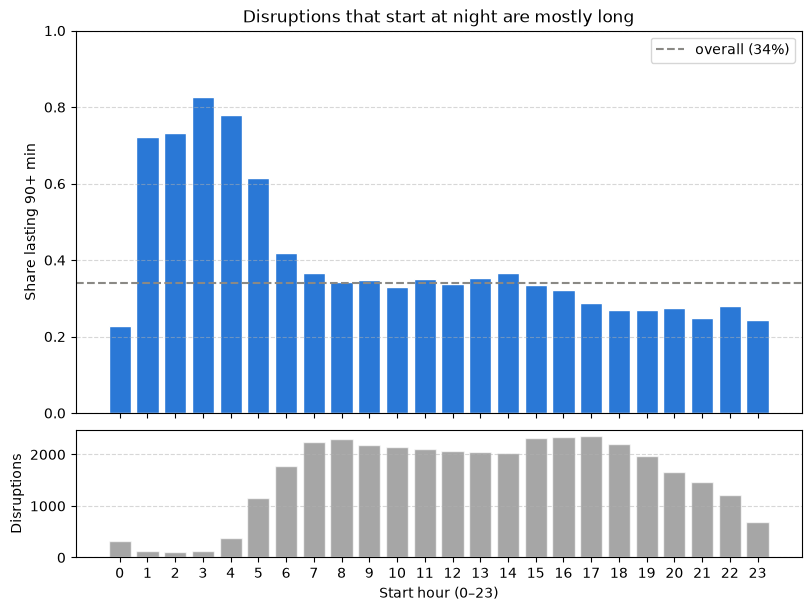

In [17]:
start_hour = df["start_time"].dt.hour
by_hour = df.groupby(start_hour).agg(n=("long", "size"), long_rate=("long", "mean"))
overall_rate = df["long"].mean()

fig, (ax_rate, ax_n) = plt.subplots(
    2,
    1,
    figsize=(8, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
    layout="constrained",
)

# Top: share of disruptions that are long, per start hour
ax_rate.bar(by_hour.index, by_hour["long_rate"], color=BAR_COLOR, edgecolor="white")
ax_rate.axhline(overall_rate, color="#8a8985", linestyle="--", label=f"overall ({overall_rate:.0%})")
ax_rate.set_ylim(0, 1)
ax_rate.set_ylabel(f"Share lasting {THRESHOLD}+ min")
ax_rate.set_title("Disruptions that start at night are mostly long")
ax_rate.grid(axis="y", linestyle="--", alpha=0.5)
ax_rate.legend(loc="upper right")

# Bottom: how many disruptions each rate is based on
ax_n.bar(by_hour.index, by_hour["n"], color="gray", edgecolor="white", alpha=0.7)
ax_n.set_ylabel("Disruptions")
ax_n.set_xlabel("Start hour (0–23)")
ax_n.set_xticks(range(24))
ax_n.grid(axis="y", linestyle="--", alpha=0.5)

fig.savefig(figures_dir / "02_long_rate_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()

**Is the night effect just a different mix of causes?** Nights could simply have more infrastructure and
engineering problems, which are long anyway. To test this, compare the **same cause group** at different times of day.

In [18]:
time_of_day = pd.cut(
    start_hour,
    bins=[-1, 0, 4, 5, 16, 23],
    labels=["0h", "1–4h (night)", "5h", "6–16h (day)", "17–23h (evening)"],
)

rate_by_cause_and_time = df.pivot_table(
    index="cause_group", columns=time_of_day, values="long", aggfunc="mean", observed=True
).round(2)
rate_by_cause_and_time

start_time,0h,1–4h (night),5h,6–16h (day),17–23h (evening)
cause_group,,,,,
accidents,0.20,0.42,0.59,0.67,0.48
engineering work,0.94,0.85,0.42,0.49,0.57
external,0.07,0.49,0.67,0.17,0.12
infrastructure,0.12,0.72,0.64,0.58,0.56
logistical,0.67,0.93,0.87,0.64,0.49
rolling stock,0.08,0.80,0.52,0.15,0.12
staff,1.00,0.98,1.00,0.94,0.83
unknown,NaN,0.00,0.20,0.15,0.15
weather,NaN,0.95,1.00,0.71,0.66


In [19]:
# How many rows are behind the night column?
pd.crosstab(df["cause_group"], time_of_day)

start_time,0h,1–4h (night),5h,6–16h (day),17–23h (evening)
cause_group,,,,,
accidents,92,52,66,2018,1536
engineering work,35,171,216,581,194
external,54,37,39,2384,2005
infrastructure,41,228,486,5829,1997
logistical,3,67,77,963,376
rolling stock,85,81,192,10597,5147
staff,2,58,71,386,70
unknown,0,4,5,537,182
weather,0,38,11,228,64


**D1 findings**

What the data shows:

- Disruptions starting between **1 and 5 a.m.** are long 62–83% of the time, against about 34% during the day and
  25–28% in the evening. Hour 0 is the exception, at only 23%.
- Nights are rare: hours 1–4 together have only about 700 disruptions out of 37,000, so these rates rest on few rows.
- It is **not just the mix of causes.** Within the same group the night effect stays: a rolling-stock disruption is
  long about 80% of the time at 1–4 a.m. (81 rows), against about 15% during the day. External causes show the same
  jump (49% vs 17%, but only 37 night rows). Not every group follows it: accidents are *less* often long at night
  (42% vs 67%, 52 night rows), so the hour effect depends on the cause.
- At hour 0 rolling-stock disruptions are even shorter than in the day (8% long).

Why (hypotheses, not tested with this data):

- The duration is how long the **message stayed open**, not how long travellers were affected. A problem at 3 a.m.
  is often only resolved, or the message only closed, shortly before morning service starts: there are no
  travellers and no urgency, so the clock keeps running.
- At 0h the regular evening service is still running; once the last trains have run, the message can be closed.
- Fewer maintenance crews at night may add to it. Staffing is not in the data.

What it means for the project:

- **Start hour is a strong feature** for notebook 03, and it is known at the start of a disruption. Because its
  effect differs per cause, a tree model (LightGBM) can use it better than a plain logistic regression.
- **Limitation:** "long" is measured in minutes of an open message. At night a long message affects few or no
  travellers, so a "long" prediction does not mean the same at 3 a.m. as at 8 a.m.

### D2. Weekday and month

Same approach as D1: the long rate per group, with the number of disruptions underneath,
in natural order (Monday → Sunday, January → December) and with the overall rate as a reference line.

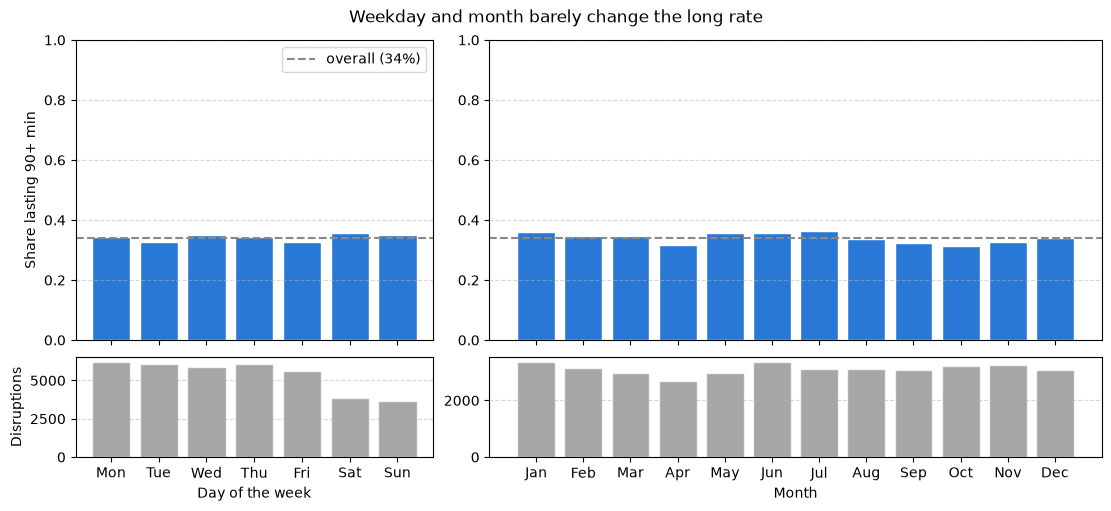

In [20]:
weekday = df["start_time"].dt.dayofweek   # 0 = Monday ... 6 = Sunday
month = df["start_time"].dt.month         # 1 = January ... 12 = December

by_weekday = df.groupby(weekday).agg(n=("long", "size"), long_rate=("long", "mean"))
by_month = df.groupby(month).agg(n=("long", "size"), long_rate=("long", "mean"))

weekday_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(11, 5),
    sharex="col",
    gridspec_kw={"height_ratios": [3, 1], "width_ratios": [7, 12]},
    layout="constrained",
)

panels = [(by_weekday, weekday_labels, "Day of the week", 0), (by_month, month_labels, "Month", 1)]
for table, labels, xlabel, col in panels:
    ax_rate, ax_n = axes[0, col], axes[1, col]

    ax_rate.bar(table.index, table["long_rate"], color=BAR_COLOR, edgecolor="white")
    ax_rate.axhline(overall_rate, color="#8a8985", linestyle="--", label=f"overall ({overall_rate:.0%})")
    ax_rate.set_ylim(0, 1)
    ax_rate.grid(axis="y", linestyle="--", alpha=0.5)

    ax_n.bar(table.index, table["n"], color="gray", edgecolor="white", alpha=0.7)
    ax_n.set_xticks(table.index, labels)
    ax_n.set_xlabel(xlabel)
    ax_n.grid(axis="y", linestyle="--", alpha=0.5)

axes[0, 0].set_ylabel(f"Share lasting {THRESHOLD}+ min")
axes[1, 0].set_ylabel("Disruptions")
axes[0, 0].legend(loc="upper right")
fig.suptitle("Weekday and month barely change the long rate")

fig.savefig(figures_dir / "02_long_rate_by_weekday_month.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
# The same numbers as a table: how far apart are the highest and lowest group?
spread = pd.DataFrame({
    "lowest rate": [by_weekday["long_rate"].min(), by_month["long_rate"].min(), by_hour["long_rate"].min()],
    "highest rate": [by_weekday["long_rate"].max(), by_month["long_rate"].max(), by_hour["long_rate"].max()],
}, index=["weekday", "month", "hour (for comparison)"])
spread["spread (points)"] = (spread["highest rate"] - spread["lowest rate"]) * 100
spread.round(3)

,lowest rate,highest rate,spread (points)
weekday,0.325,0.358,3.292
month,0.314,0.363,4.892
hour (for comparison),0.228,0.827,59.950


**D2 findings**

- **Weekday:** the long rate stays between about 32.5% (Tue, Fri) and 36% (Sat, Sun). Weekends have fewer
  disruptions (~3,700 vs ~6,000 per weekday) and are slightly more often long, a difference of 2–3 points.
- **Month:** between about 31% (October) and 36% (January, July). There is no clear seasonal pattern; autumn is a
  little lower, but the differences are small and not consistent.
- **Compared with the hour of day** (a spread of about 60 points), weekday and month spread only 3–5 points.

**What it means for notebook 03:**

- Month looks like noise: it is left out, so the model cannot learn year-specific accidents as if they were seasons.
- Weekday is weak; at most a single `is_weekend` flag (Saturday/Sunday) is worth trying.
- The hour of day stays the main time feature.

## E. Lines

- **E1.** Number of lines affected: `rdt_lines_id.str.count(",") + 1`, capped with `.clip(upper=5)`. Long rate per value.
- **E2.** Explode the lines (`str.split(",")` then `.explode()`); top 15 lines by number of disruptions with their long rate.

### E1. Number of lines affected

In [ ]:
df["n_lines"] = (df["rdt_lines_id"].str.count(",") + 1).clip(upper=5).astype("Int64")

print("Rows without a line (left out of the table):", df["n_lines"].isna().sum())
df.groupby("n_lines").agg(n=("long", "size"), long_rate=("long", "mean")).round(3)

The long rate goes up and down between 30% and 37% with no trend as more lines are affected
(5 means 5 or more). **The number of lines affected is a weak feature.** The 7 rows without a line are left out.

### E2. Long rate per line

A disruption can affect several lines. To get one row per (disruption, line), split `rdt_lines` on `", "` and
**explode the whole table**, so the `long` column stays next to each line.
After exploding, one disruption on 3 lines counts 3 times: the row count is no longer the number of disruptions,
but the rate per line is still correct.

In [ ]:
lines = df.assign(line=df["rdt_lines"].str.split(", ")).explode("line")
print(f"Rows after exploding: {len(lines):,} (from {len(df):,} disruptions)")
print("Distinct lines:", lines["line"].nunique())

by_line = lines.groupby("line").agg(n=("long", "size"), long_rate=("long", "mean"))

# groupby sorts alphabetically, so sort by size to get the busiest lines
by_line.sort_values("n", ascending=False).head(15).round(3)

In [ ]:
# Lines with enough data for a reliable rate: lowest and highest 3
reliable = by_line[by_line["n"] >= 300].sort_values("long_rate")
print("Lines with at least 300 rows:", len(reliable))
pd.concat([reliable.head(3), reliable.tail(3)]).round(3)

In [ ]:
print("Lines with fewer than 30 rows:", (by_line["n"] < 30).sum())
by_line[by_line["n"] < 30].sort_values("n")

**E findings**

- The busiest lines are all in the Randstad and around Schiphol (about 1,000–1,800 rows each), with long rates of
  about 23–38%, close to or below the overall 34%.
- Among lines with at least 300 rows, the rate ranges from about **21%** (Tiel – Utrecht Centraal) to about **70%**.
  The highest are **cross-border and regional lines in the east**: Hengelo – Oldenzaal, Aachen – Heerlen,
  Bielefeld – Hengelo.
- Hypothesis: on busy core lines a broken train is cleared quickly because there are spare trains, staff and
  alternatives nearby; on single-track, cross-border lines run by other operators, repairs and replacements take
  longer. The data shows the difference, not the reason.
- 8 lines have fewer than 30 rows: their rates are unreliable, like the rare causes in C3.

**What it means for notebook 03:**

- The line carries real information, but one disruption can affect several lines and there are 111 distinct lines.
  A simple option is to use the **first listed line** as a category, with rare lines grouped into `"other"`
  (decided on the training years only), or a flag for cross-border lines.
- The number of lines affected is weak and can be left out or kept as a minor feature.

## F. Leakage check

The prediction is made **when the disruption is announced**. A column may only become a feature if its value is
known at that moment. Three questions per column: when does the value exist, could it change while the disruption
is running (the data only stores the final version), and even if it is known, is it a sensible feature?

| Column | Known at start? | Why | Use as feature? |
|---|---|---|---|
| `rdt_id` | yes | Assigned when the message is created | **No.** IDs count up over time, so they encode the date; every 2025 ID is larger than anything seen in training |
| `ns_lines` | yes | Free text from the NS message | **No.** Unstructured; `rdt_lines` is the clean version |
| `rdt_lines`, `rdt_lines_id` | partly | Lines are known at the start, but the data holds the final list and a disruption can spread | **Yes** (line information), limitation noted |
| `rdt_station_names`, `rdt_station_codes` | partly | Same as lines: the final list | Not for now; lines already cover location |
| `cause_en`, `cause_nl` | partly | In the announcement, but stored as the *final* cause | **Yes**, `cause_en` only (`cause_nl` says the same thing), limitation noted |
| `statistical_cause_*` | **no** | Can contain the cause found out later (notebook 01) | **Never** |
| `cause_group` | partly | Derived from `cause_en` | **Yes** |
| `start_time` | yes | This *is* the moment of prediction | Only through derived features (hour, weekend); the raw timestamp would encode the date, like `rdt_id` |
| `end_time` | **no** | Only exists when the disruption ends | **Never** |
| `duration_minutes` | **no** | Computed from `end_time`; the source of the target | **Never** |
| `long` | **no** | The target itself | Target only |
| `year` | yes | Known, but 2025 is a value the model never saw in training | **No**; used only for the train / validation / test split |
| `n_lines` | partly | Built from the final line list | Optional (weak in E1) |

Two rules behind the table:

- **Known at the start is necessary but not enough.** `rdt_id`, `year` and the raw `start_time` are known, but they
  would let the model learn *when* a disruption happened instead of *what* it was, which stops working on new years.
- **Partly is not the same as no.** Lines and causes are stored in their final version and we cannot check how often
  they changed during a disruption. They are used, and this is written down as a limitation.

In [ ]:
# Source columns allowed into notebook 03, and the features planned from them
ALLOWED_COLUMNS = ["cause_en", "cause_group", "rdt_lines", "rdt_lines_id", "start_time"]

PLANNED_FEATURES = {
    "cause_en": "specific cause; causes rare in the training years -> 'other'",
    "cause_group": "broad cause type",
    "start_hour": "hour of start_time (strongest time feature, section D1)",
    "is_weekend": "Saturday or Sunday (weak, section D2)",
    "line": "first listed line, rare lines -> 'other' (section E2)",
    "n_lines": "number of lines affected, capped at 5 (optional, weak in E1)",
}

NEVER_USE = ["end_time", "duration_minutes", "statistical_cause_en", "statistical_cause_nl", "rdt_id", "year"]

pd.Series(PLANNED_FEATURES, name="from / why")

## G. Figures

Saved in `reports/figures/` for the README:

| File | Shows |
|---|---|
| `02_duration_hist.png` | Duration distribution on a log scale (two humps, long tail) |
| `02_long_rate_by_cause_group.png` | Long rate per cause group, strikes removed |
| `02_long_rate_by_hour.png` | Long rate and volume per start hour |
| `02_long_rate_by_weekday_month.png` | Long rate and volume per weekday and month |

## Summary: decisions for notebook 03

**Target and scope**

- A disruption is **long** if it lasts **90 minutes or more** (34.9% of disruptions). The threshold is fixed.
- **Strikes are out of scope** (472 rows): `cause_group == "staff"` and `cause_en` containing "strike" or "staking".
  37,305 disruptions remain. Notebook 03 applies exactly the same rule.

**What separates long from short**

1. **Cause** is by far the strongest signal: from 4% long (person on the track) to 86% (person hit by a train).
2. **Start hour**: disruptions starting between 1 and 5 a.m. are long 62–83% of the time, even within the same cause
   group. The effect differs per cause, which favours a tree model.
3. **Line**: busy Randstad lines are 23–38% long; some cross-border and regional lines in the east about 70%.
4. **Weak or no signal**: weekday (3 points), month (5 points), number of lines affected.

**Watch out for**

- Rare causes and rare lines: group them into `"other"`, decided on the training years only.
- The *unknown* / `technical investigation` category grows sharply in 2024–2025 (validation and test years).
- 2023 has a higher long rate than other years, only partly explained by strikes.
- "Long" means a message stayed open 90+ minutes, not that travellers were affected that long (especially at night).
- Leakage: never use `end_time`, `duration_minutes`, `statistical_cause_*`, `rdt_id` or `year` as features.